In [102]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [103]:
words = open('/Users/raghav/Downloads/names.txt').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [104]:
len(words)

32033

In [105]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [106]:
#dataset

block_size = 3
X = []
Y = []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [107]:
X.shape , X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [108]:
C = torch.randn(27,2)
C[5]

tensor([-0.2097, -0.1528])

In [109]:
C[X].shape

torch.Size([228146, 3, 2])

In [110]:
X[13,2].item()

1

In [111]:
C[X]

tensor([[[-0.8297, -0.6154],
         [-0.8297, -0.6154],
         [-0.8297, -0.6154]],

        [[-0.8297, -0.6154],
         [-0.8297, -0.6154],
         [-0.2097, -0.1528]],

        [[-0.8297, -0.6154],
         [-0.2097, -0.1528],
         [ 0.4227,  1.5502]],

        ...,

        [[ 0.1087, -0.1447],
         [ 0.1087, -0.1447],
         [ 0.2197, -0.5235]],

        [[ 0.1087, -0.1447],
         [ 0.2197, -0.5235],
         [ 0.1087, -0.1447]],

        [[ 0.2197, -0.5235],
         [ 0.1087, -0.1447],
         [ 1.7208, -1.3981]]])

In [112]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [149]:
W1 = torch.randn(6,100)
b1 = torch.randn(100)
W1

tensor([[ 1.4498e+00,  1.7419e+00,  6.2920e-01, -1.3194e-01,  8.5897e-01,
         -1.4503e-01, -5.9770e-01, -2.1282e-01,  2.9894e-01,  8.9456e-01,
         -1.3212e-01,  1.6675e+00, -3.9277e-01, -1.9859e+00,  2.2821e-01,
          4.5861e-01,  1.6330e+00, -1.1598e-01,  1.2129e-01,  1.2027e+00,
          6.3295e-02,  7.5587e-01, -4.3121e-02, -7.4881e-01, -2.2843e+00,
          1.6297e+00,  6.8605e-01, -1.1875e+00, -7.4992e-01,  2.5996e-01,
         -9.9622e-02,  8.6397e-01,  7.6457e-01, -5.4602e-01, -6.4340e-02,
          9.7611e-01,  7.5973e-01,  1.0679e+00, -1.2860e+00, -6.5298e-03,
          1.3791e+00,  7.2641e-01,  5.9432e-01,  8.3569e-02,  5.0356e-01,
         -1.5369e-01,  1.4556e-01, -1.9014e-03, -1.4868e-01, -1.4821e+00,
         -4.5780e-01,  7.6345e-01,  3.3304e-01, -1.5373e+00,  4.8993e-01,
          1.0344e+00,  1.3427e+00, -2.6797e-01, -6.6965e-01, -1.3550e+00,
          3.9586e-01,  6.6480e-01,  1.0352e-03,  9.5014e-02,  1.2780e+00,
          1.2735e+00,  4.0904e-01,  1.

In [171]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [218]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator = g)
W1 = torch.randn((6,300),generator = g)
b1 = torch.randn(300, generator = g)
W2 = torch.randn((300,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

In [219]:
for p in parameters:
    p.requires_grad = True

In [220]:
lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre 

In [221]:
lri = []
lossi = []


for i in range(10000):
    #mini batch construct
    ix = torch.randint(0,X.shape[0],(32,))
    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims = True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
 
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    # lri.append(lre[i])
    #lossi.append(loss.item())


print(loss.item())

2.7551615238189697


In [195]:
#train split, #dev/validation split ,#test split

#building the dataset 

def build_dataset(words):
    block_size = 3
    X,Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape)
    print(Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3])
torch.Size([182625])
torch.Size([22655, 3])
torch.Size([22655])
torch.Size([22866, 3])
torch.Size([22866])


In [197]:
C = torch.randn(27,2)

In [242]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10),generator = g)
W1 = torch.randn((30,200),generator = g)
b1 = torch.randn(200, generator = g)
W2 = torch.randn((200,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

In [243]:
for p in parameters:
    p.requires_grad = True

In [244]:
sum(p.nelement() for p in parameters)

11897

In [245]:
lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre 

In [246]:
lri = []
lossi = []
stepi = []

In [257]:

for i in range(50000):
    #mini batch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims = True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
 
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())


#print(loss.item())

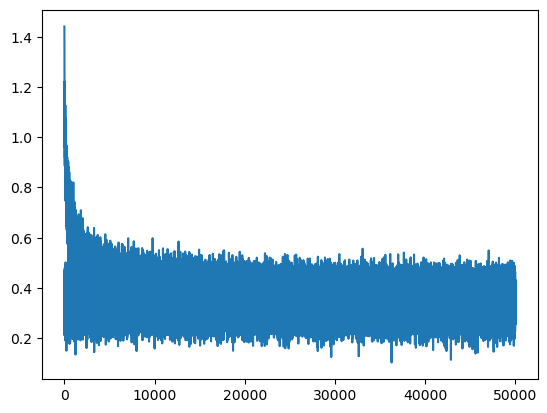

In [258]:
plt.plot(stepi,lossi)

In [259]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.2561, grad_fn=<NllLossBackward0>)

In [260]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.3059, grad_fn=<NllLossBackward0>)

In [269]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim = 1)
        ix = torch.multinomial(probs,num_samples = 1,generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    # print(''.join(itos[i]) for i in out))
    print(''.join(itos[i] for i in out))
 

carlah.
quelle.
mikimrin.
tatyah.
cassa.
jazheenadeerahciareen.
neemarahceriavon.
leigh.
ham.
prin.
quinton.
lilah.
jamarionne.
madearyxix.
kaelynn.
abbed.
emi.
abettefeysalyah.
asmonda.
ksyah.


In [ ]:
brr